# Analiza zbioru danych

## Importy i wczytanie danych

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/Customer-Churn-Records.csv")
display(df.shape)
df.head()

(10000, 18)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [10]:
print(df.info())
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  str    
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  str    
 5   Gender              10000 non-null  str    
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card Type       

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


Row Number, Customer Id oraz surname nic nie wnoszą, możemy je usunąć.

## Brakujące wartości

In [3]:
df.isna().sum()

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

Brak pustych kolumn, nie trzeba nic usuwać.

## Rozkład klas

In [4]:
df["Exited"].value_counts(normalize=True)

Exited
0    0.7962
1    0.2038
Name: proportion, dtype: float64

Niezbalansowane klasy: (około) 80% klientów zostaje, 20% odchodzi.

## Rozkłady cech numerycznych

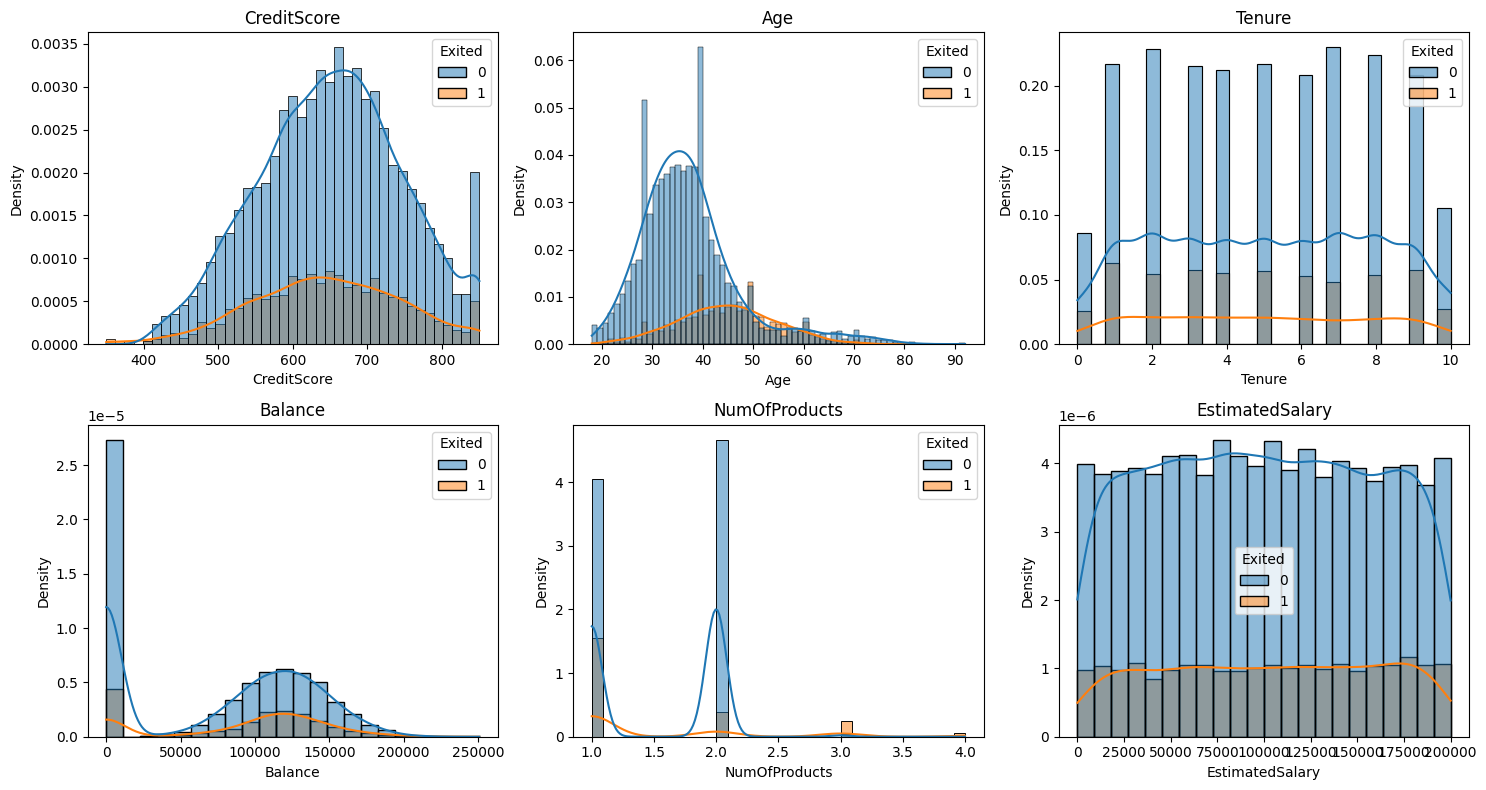

In [5]:
numeric = ["CreditScore", "Age", "Tenure", "Balance", 
           "NumOfProducts", "EstimatedSalary"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, numeric):
    sns.histplot(data=df, x=col, hue="Exited", kde=True, ax=ax, stat="density")
    ax.set_title(col)
plt.tight_layout()


- Age - starsi klienci częściej odchodzą.
- Balance - klienci odchodzący częściej mają niezerowe saldo.

## Rozkłady cech kategorycznych

In [6]:
for col in ["Geography", "Gender", "HasCrCard", "IsActiveMember", "NumOfProducts"]:
    print(col, df.groupby(col)["Exited"].mean().round(3).to_dict())

Geography {'France': 0.162, 'Germany': 0.324, 'Spain': 0.167}
Gender {'Female': 0.251, 'Male': 0.165}
HasCrCard {0: 0.208, 1: 0.202}
IsActiveMember {0: 0.269, 1: 0.143}
NumOfProducts {1: 0.277, 2: 0.076, 3: 0.827, 4: 1.0}


- Geography: Niemcy 32% vs Francja/Hiszpania 16% - Niemcy odchodzą 2x częściej
- Gender:  Kobiety 25% vs Mężczyźni 16.5% 
- IsActiveMember: nieaktywni 27% vs aktywni 14%
- NumOfProducts: klienci z 3-4 produktami praktycznie zawsze odchodzą

## Korelacje między cechami

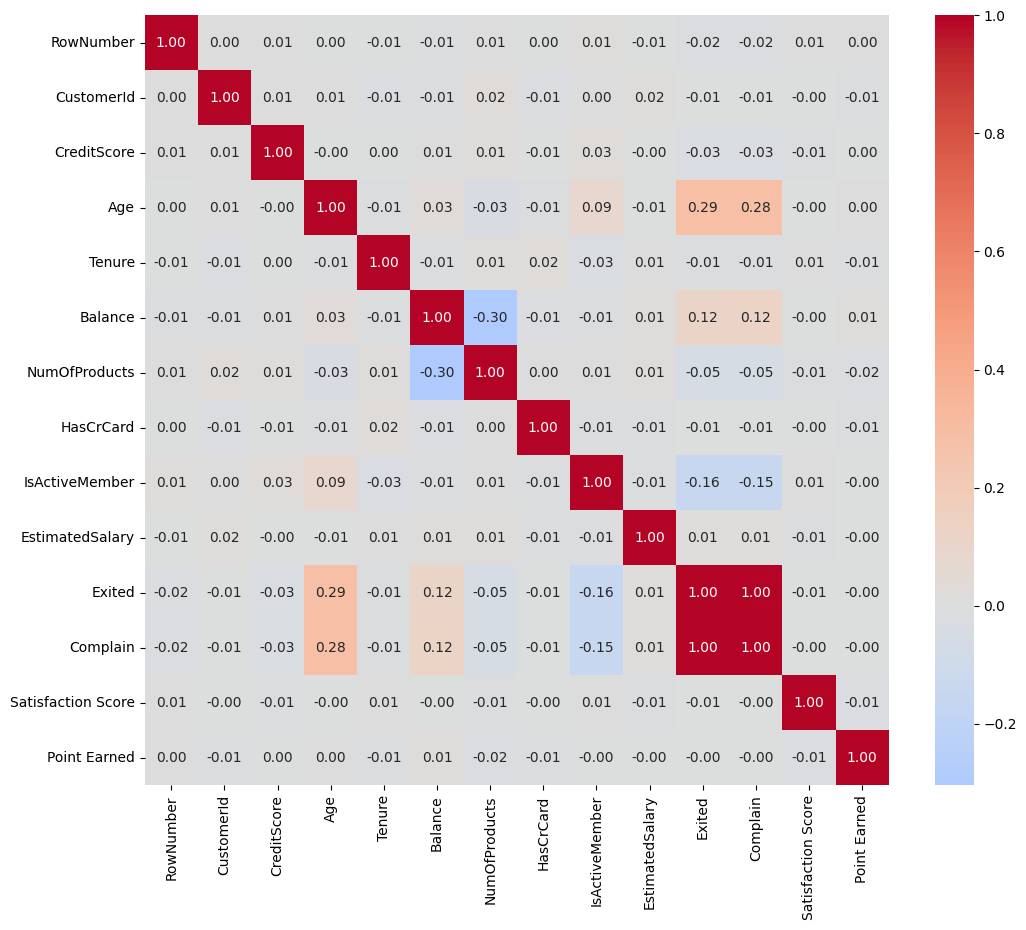

In [11]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.select_dtypes(include="number").corr(), 
            annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.show()

- Complain ma korelację w zaokrągleniu 1 z Exited - wyrzucamy.
- Age ma najsilniejszą liniową korelację z targetem (0.29).

## Outliery

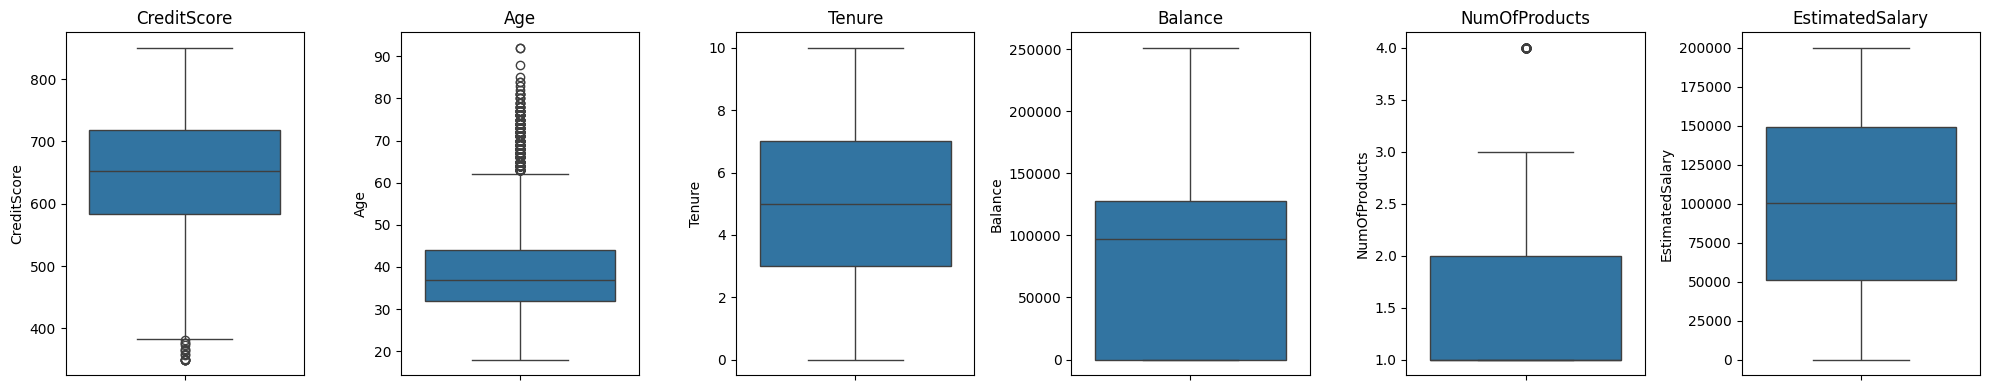

In [8]:
fig, axes = plt.subplots(1, len(numeric), figsize=(20, 4))
for ax, col in zip(axes, numeric):
    sns.boxplot(data=df, y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

- CreditScore - pojedyncze punkty na dole (słaba historia kredytowa).
- Age - sporo klientów powyżej 62 lat.
- NumOfProducts - klienci z 4 produktami pojawiają się jako pojedynczy punkt odstający, jest ich niewielu.

Wszystkie te wartości to nie błędy w danych, tylko rzadziej spotykani klienci. Dodatkowo klienci z 4 produktami to grupa, która najsilniej wiąże się z odejściem z banku, więc usunięcie ich pogorszyłoby model.

## Pozostałe cechy

In [9]:
print(df.groupby("NumOfProducts")["Exited"].agg(["count", "mean"]).round(3))
print(df.groupby("Satisfaction Score")["Exited"].agg(["count", "mean"]).round(3))
print(df.groupby("Card Type")["Exited"].agg(["count", "mean"]).round(3))

               count   mean
NumOfProducts              
1               5084  0.277
2               4590  0.076
3                266  0.827
4                 60  1.000
                    count   mean
Satisfaction Score              
1                    1932  0.200
2                    2014  0.218
3                    2042  0.196
4                    2008  0.206
5                    2004  0.198
           count   mean
Card Type              
DIAMOND     2507  0.218
GOLD        2502  0.193
PLATINUM    2495  0.204
SILVER      2496  0.201


- Przy NumOfProducts ponownie widać, że osoby z 4 produktami zawsze odchodzą, natomiast z 3 w 83% co jest bardzo wysokim wynikiem.
- Satisfaction Score oraz Card Type nie wpływa praktycznie w ogóle na odejście.

## Wnioski końcowe

Zbiór zawiera 10000 klientów banku, target to kolumna Exited (czy klient odszedł).

**Z datasetu usuwamy:**
- RowNumber, CustomerId, Surname - identyfikatory bez wartości.
- Complain - korelacja prawie 1.00 z targetem.

Klasy są niezbalansowane (80/20), więc accuracy będzie myląca. Cechy mają bardzo różne skale, potrzebne skalowanie.

**Najsilniejsze predyktory odejścia:**
- NumOfProducts (3-4 produkty praktycznie zawsze = odejście)
- Age (starsi odchodzą częściej, korelacja 0.29)
- Geography (Niemcy 32% vs Francja/Hiszpania 16%)
- IsActiveMember (nieaktywni 27% vs aktywni 14%)
- Gender (kobiety 25% vs mężczyźni 16.5%)

Bez sygnału: CreditScore, Tenure, HasCrCard, EstimatedSalary, Satisfaction Score, Card Type, Point Earned.

Outliery zostawiamy.